# Support vector machines: the widest street, and a change of coordinates

Two approaches so far. k-nearest neighbours **remembered** the data and lost its
footing in high dimensions. Naive Bayes **assumed** a structure and failed when
the structure was an interaction.

The support vector machine does something different again, in two steps that are
worth separating because they are usually taught mashed together.

**Step one: among all the lines that separate the classes, pick a particular
one** — the one with the most room on either side. That is the margin, and it is
a genuinely different idea from "minimise the error", because on separable data
every one of those lines has zero error.

**Step two: when no line works, change coordinates until one does.** This is the
kernel trick, and it turns the linear method of step one into something that can
draw the ring boundary of notebook 1.

By the end you will have watched a linear SVM score the base rate on the pumps,
and the same algorithm with one argument changed score 0.947.

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from pump_data import load_pumps

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E7D8A", "#9C4221", "#F0BE50"
INK, SLATE = "#1A1A1A", "#4A5568"
plt.rcParams.update({
    "font.size": 11, "axes.edgecolor": SLATE, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": SLATE, "ytick.color": SLATE,
})

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

X, y = load_pumps()
scaler = StandardScaler().fit(X)
Z = pd.DataFrame(scaler.transform(X), columns=X.columns)
baseline = max(y.mean(), 1 - y.mean())
print(f"{len(X)} pumps, majority baseline {baseline:.3f}")

1200 pumps, majority baseline 0.613


## 1. The widest street

Take a problem where a line *does* separate the classes. There are infinitely
many such lines, and lesson 4's logistic regression picks one by minimising log
loss — a perfectly good criterion, and not the only one available.

The support vector machine picks the line with the **widest margin**: push a
slab outwards from the boundary on both sides until it touches the nearest
points of each class, and choose the boundary that makes that slab as thick as
possible.

**The intuition for why that is a sensible thing to want.** A boundary that
passes close to a training point is one small change away from getting that
point wrong. Maximising the distance to the closest points is choosing the
boundary that tolerates the most movement in the data before it changes its
mind — which is a statement about generalisation rather than about fit.

The points that end up touching the slab are the **support vectors**. They alone
determine the boundary: move any other point, or delete it, and the answer does
not change. Let us see that on a small separable example.

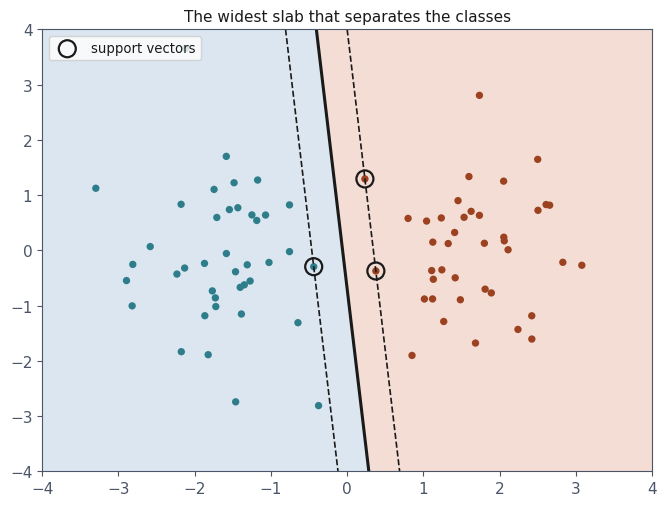

80 points, 3 of them support vectors


In [2]:
rng = np.random.default_rng(3)
left = rng.normal([-1.6, 0.0], [0.6, 1.1], size=(40, 2))
right = rng.normal([+1.6, 0.0], [0.6, 1.1], size=(40, 2))
toy = np.vstack([left, right])
toy_y = np.r_[np.zeros(40, dtype=int), np.ones(40, dtype=int)]

linear = SVC(kernel="linear", C=1_000).fit(toy, toy_y)

grid_x, grid_y = np.meshgrid(np.linspace(-4, 4, 300), np.linspace(-4, 4, 300))
decision = linear.decision_function(
    np.c_[grid_x.ravel(), grid_y.ravel()]).reshape(grid_x.shape)

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.contourf(grid_x, grid_y, decision > 0, levels=[-0.5, 0.5, 1.5],
            colors=["#DCE6F0", "#F3DDD4"])
ax.contour(grid_x, grid_y, decision, levels=[-1, 0, 1], colors=[INK],
           linestyles=["--", "-", "--"], linewidths=[1.2, 2.2, 1.2])
ax.scatter(toy[toy_y == 0, 0], toy[toy_y == 0, 1], s=28, color=TEAL,
           edgecolor="none")
ax.scatter(toy[toy_y == 1, 0], toy[toy_y == 1, 1], s=28, color=RUST,
           edgecolor="none")
ax.scatter(linear.support_vectors_[:, 0], linear.support_vectors_[:, 1],
           s=150, facecolor="none", edgecolor=INK, linewidth=1.6,
           label="support vectors")
ax.set_title("The widest slab that separates the classes", fontsize=11)
ax.legend(loc="upper left", fontsize=9.5)
fig.tight_layout()
fig.savefig(FIGURES / "svm_margin.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

print(f"{len(toy)} points, {linear.n_support_.sum()} of them support vectors")

The solid line is the boundary; the dashed lines mark the edges of the slab; the
circled points are the support vectors touching it.

**Only a handful of points matter.** That is the first practically useful
property of this method: the fitted model is described by a few points and their
weights, not by the whole dataset — unlike k-NN, which has to keep everything.

## 2. Soft margins, and the one knob

Real data is not separable, and the pumps have 4% of their labels flipped on
purpose. A hard margin has no answer at all in that situation.

The fix is to allow violations and charge for them. The parameter **C** sets the
price:

- **Large C** — violations are expensive, so the model contorts to classify
  every training point. Narrow margin, low bias, high variance.
- **Small C** — violations are cheap, so the model accepts some errors in
  exchange for a wider, calmer boundary. Wide margin, higher bias, lower
  variance.

It is the same dial as $k$ in notebook 1 and the penalty $\lambda$ in lesson 3,
wearing a third costume. Note the direction, which catches people out:
**large C means less regularisation.**

## 3. On the pumps, a straight line still fails

Before the kernel, confirm that the margin idea alone does not rescue us. The
problem in notebook 1 was not which line to choose — it was that no line
works.

In [3]:
for name, model in (("SVM, linear kernel", SVC(kernel="linear")),
                    ("SVM, RBF kernel", SVC(kernel="rbf"))):
    scores = cross_val_score(make_pipeline(StandardScaler(), model), X, y,
                             cv=folds, scoring="accuracy")
    print(f"  {name:<22} {scores.mean():.3f} +/- {scores.std():.3f}")
print(f"  {'majority baseline':<22} {baseline:.3f}")

for kernel in ("linear", "rbf"):
    fitted = SVC(kernel=kernel).fit(Z, y)
    n = fitted.n_support_.sum()
    print(f"\n  {kernel:<7} {n} support vectors of {len(Z)} points "
          f"({n / len(Z):.0%})")

  SVM, linear kernel     0.613 +/- 0.000
  SVM, RBF kernel        0.947 +/- 0.005
  majority baseline      0.613

  linear  947 support vectors of 1200 points (79%)

  rbf     278 support vectors of 1200 points (23%)


**The linear kernel scores the base rate**, exactly as logistic regression did.
Choosing the best straight line is no help when the best straight line is
useless.

Look at the support vector counts, which say why in a different language. The
linear model needs **79% of the training set** as support vectors: almost every
point is sitting on or inside the margin, because there is no slab that
separates anything. The RBF model needs 23% — it has found a boundary that most
of the data sits comfortably away from.

**A high support-vector fraction is a warning sign**, and a free one: it says the
model is struggling to find room, and it costs nothing to look at.

## 4. The kernel trick

Here is the idea that makes the method famous.

**The picture first.** Our healthy pumps sit in a disc and the faulty ones
around it. No line separates them *in the plane*. But add a third coordinate —
the distance from the centre — and lift each point to that height. The healthy
pumps rise to low heights, the faulty ones to high heights, and now a flat
horizontal plane separates them perfectly.

The classes were always separable. They just needed the right coordinates.

That is the whole idea: map the data into a higher-dimensional space where a
linear boundary works, and run the linear method there. The catch is that useful
spaces are enormous — sometimes infinite-dimensional — and computing the
coordinates would be impossible.

**The trick** is that the SVM never needs the coordinates. Everything in its
solution depends on the data only through **inner products** between pairs of
points, and for the right maps there is a function $K(x, x')$ that returns the
inner product *in the new space* while computing only with the original one.

$$K(x, x') = \langle \phi(x), \phi(x') \rangle \quad \text{without ever forming } \phi(x)$$

The common choice, and scikit-learn's default, is the **radial basis function**:

$$K(x, x') = \exp\left(-\gamma \lVert x - x' \rVert^2\right)$$

which corresponds to an infinite-dimensional space — and costs one exponential
per pair.

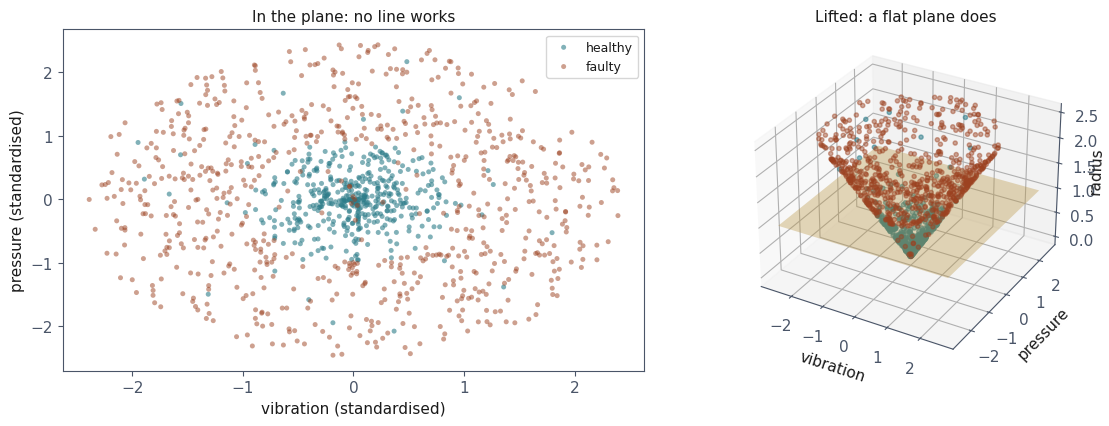

In [4]:
# The lift that makes this problem separable, drawn explicitly.
radius = np.sqrt((Z ** 2).sum(axis=1))

fig = plt.figure(figsize=(12.2, 4.4))

ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(Z.loc[y == 0, "vibration_hz"], Z.loc[y == 0, "pressure_bar"],
            s=13, color=TEAL, alpha=.6, edgecolor="none", label="healthy")
ax1.scatter(Z.loc[y == 1, "vibration_hz"], Z.loc[y == 1, "pressure_bar"],
            s=13, color=RUST, alpha=.5, edgecolor="none", label="faulty")
ax1.set_xlabel("vibration (standardised)")
ax1.set_ylabel("pressure (standardised)")
ax1.set_title("In the plane: no line works", fontsize=11)
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(Z.loc[y == 0, "vibration_hz"], Z.loc[y == 0, "pressure_bar"],
            radius[y == 0], s=9, color=TEAL, alpha=.55)
ax2.scatter(Z.loc[y == 1, "vibration_hz"], Z.loc[y == 1, "pressure_bar"],
            radius[y == 1], s=9, color=RUST, alpha=.45)
plane_x, plane_y = np.meshgrid(np.linspace(-2.6, 2.6, 2),
                               np.linspace(-2.6, 2.6, 2))
ax2.plot_surface(plane_x, plane_y, np.full_like(plane_x, 1.0),
                 color=GOLD, alpha=.35)
ax2.set_xlabel("vibration"); ax2.set_ylabel("pressure")
ax2.set_zlabel("radius", labelpad=-4)
ax2.set_title("Lifted: a flat plane does", fontsize=11)

fig.tight_layout()
fig.savefig(FIGURES / "kernel_lift.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

The same 1,200 pumps, twice. On the left, in the plane where we measured them:
hopeless for a line. On the right, with one extra coordinate: the gold plane
separates them cleanly.

We picked that third coordinate by knowing the answer. **The RBF kernel does
something equivalent without being told**, which is why it works on problems
where nobody could guess the right lift.

## 5. Gamma, C, and what they do to the boundary

Two parameters, and they interact.

**$\gamma$** sets how far a single training point's influence reaches. Small
$\gamma$ means a wide reach and a smooth boundary; large $\gamma$ means each
point influences only its immediate neighbourhood, and the boundary can become a
collection of small islands around individual points.

**C**, as before, sets the price of a training error.

Large $\gamma$ with large C is how an RBF SVM overfits, and it does so
spectacularly: it can achieve a perfect training score on any dataset by
wrapping a tiny bubble around every point. Lesson 5's machinery is how you avoid
choosing that.

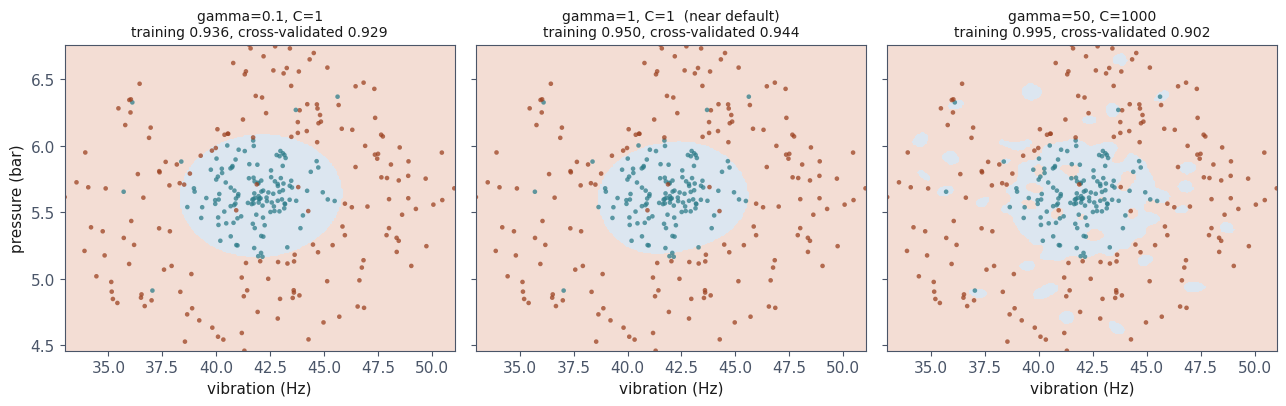

In [5]:
grid_v = np.linspace(X["vibration_hz"].min(), X["vibration_hz"].max(), 220)
grid_p = np.linspace(X["pressure_bar"].min(), X["pressure_bar"].max(), 220)
vv, pp = np.meshgrid(grid_v, grid_p)
query = pd.DataFrame({"vibration_hz": vv.ravel(), "pressure_bar": pp.ravel()})

settings = [("gamma=0.1, C=1", 0.1, 1.0),
            ("gamma=1, C=1  (near default)", 1.0, 1.0),
            ("gamma=50, C=1000", 50.0, 1_000.0)]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
sample = np.random.default_rng(0).choice(len(X), 300, replace=False)

for ax, (title, gamma, C) in zip(axes, settings):
    model = make_pipeline(StandardScaler(),
                          SVC(kernel="rbf", gamma=gamma, C=C)).fit(X, y)
    zone = model.predict(query).reshape(vv.shape)
    ax.contourf(vv, pp, zone, levels=[-0.5, 0.5, 1.5],
                colors=["#DCE6F0", "#F3DDD4"])
    ax.scatter(X.iloc[sample]["vibration_hz"], X.iloc[sample]["pressure_bar"],
               c=[TEAL if v == 0 else RUST for v in y.iloc[sample]],
               s=11, alpha=.75, edgecolor="none")
    cv = cross_val_score(make_pipeline(StandardScaler(),
                                       SVC(kernel="rbf", gamma=gamma, C=C)),
                         X, y, cv=folds, scoring="accuracy").mean()
    ax.set_title(f"{title}\ntraining {model.score(X, y):.3f}, "
                 f"cross-validated {cv:.3f}", fontsize=10)
    ax.set_xlabel("vibration (Hz)")

axes[0].set_ylabel("pressure (bar)")
fig.tight_layout()
fig.savefig(FIGURES / "svm_gamma_c.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

Read the two numbers in each title together, exactly as lesson 5 taught.

The middle setting is the one to want. The right-hand one has the **higher
training score and the lower cross-validated score** — the signature of
overfitting, and here you can also see it: the boundary has broken into islands
around individual points, including the mislabelled ones.

Choosing between these three by looking at the training score would pick the
worst model with complete confidence.

## 6. The three methods, side by side

Everything from this lesson on the same problem, with the honest comparison
lesson 5 would demand.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

ALL = {
    "majority baseline": None,
    "logistic regression (lesson 4)": LogisticRegression(max_iter=2_000),
    "SVM, linear kernel": SVC(kernel="linear"),
    "Gaussian Naive Bayes": GaussianNB(),
    "k-NN, k=5": KNeighborsClassifier(5),
    "SVM, RBF kernel": SVC(kernel="rbf"),
}

rows = []
for name, model in ALL.items():
    if model is None:
        rows.append({"model": name, "accuracy": baseline, "std": 0.0})
        continue
    scores = cross_val_score(make_pipeline(StandardScaler(), model), X, y,
                             cv=folds, scoring="accuracy")
    rows.append({"model": name, "accuracy": scores.mean(), "std": scores.std()})

comparison = pd.DataFrame(rows).set_index("model")
print(comparison.to_string(float_format=lambda v: f"{v:.3f}"))
print(f"\nnoise ceiling: about 0.96 (4% of labels are flipped)")

                                accuracy   std
model                                         
majority baseline                  0.613 0.000
logistic regression (lesson 4)     0.613 0.000
SVM, linear kernel                 0.613 0.000
Gaussian Naive Bayes               0.933 0.010
k-NN, k=5                          0.944 0.006
SVM, RBF kernel                    0.947 0.005

noise ceiling: about 0.96 (4% of labels are flipped)


Three methods reach the ceiling, and they do it by three completely different
routes: remembering the neighbourhood, assuming independence, and bending the
space. Two do not, and both are linear.

**The gap between the best and worst model here is 0.33 accuracy** — larger than
any difference this course has shown between a good model and a tuned one. That
is the real lesson of the comparison: **choosing the right family of model
matters far more than tuning the wrong one**, and the way you tell which family
you need is by looking at the data first.

## What to take away

- **The margin is a different criterion from the error.** On separable data
  every separating line has zero error; the widest slab is the one that tolerates
  the most movement before it changes its mind.
- **Support vectors are the model.** Only the points on the margin matter, which
  is why an SVM is compact where k-NN is not.
- **C prices training errors, and large C means less regularisation.** The same
  dial as $k$ and $\lambda$, pointing the other way.
- **The kernel trick separates by changing coordinates**, using inner products
  in a space whose coordinates are never computed. The lift picture is what it
  is doing.
- **A high support-vector fraction is a free warning.** 79% for the linear
  kernel here, 23% for the RBF.
- **Choosing the family beats tuning the wrong one**: 0.61 to 0.95 across the
  models in this lesson, on identical data.

### Homework

`Exercises/06_knn_naive_bayes_svm.md`, due **Friday 6 November 2026**.